In [1]:
# LightGBM + MAPIE Conformal Prediction — Ames Housing
# Point predictions with 90% coverage-guaranteed prediction intervals using split conformal prediction.

## 1. Imports

In [2]:
!pip install lightgbm mapie

In [3]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMRegressor
from mapie.regression import SplitConformalRegressor  # MapieRegressor renamed in MAPIE v1.0+

## 2. Load Dataset
Downloads the Ames Housing dataset from OpenML on first run and caches it to `data/ames_housing.csv`.

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# create data folder
os.makedirs("data", exist_ok=True)

# load your full dataset
df = pd.read_csv("/Users/simardhanda/Desktop/research/data/AmesHousing.csv")

# split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# save
train_df.to_csv("data/train.csv", index=False)
test_df.to_csv("data/test.csv", index=False)

print("Split done")

Split done


In [5]:
TRAIN_PATH = os.path.join("data", "train.csv")
TEST_PATH  = os.path.join("data", "test.csv")

# Load and merge both files, then shuffle
df = pd.concat([pd.read_csv(TRAIN_PATH), pd.read_csv(TEST_PATH)], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Loaded {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)

Loaded 2930 rows × 82 columns


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1835,533205110,120,FV,45.0,4379,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,7,2007,WD,Normal,214000
1,2780,907194130,60,RL,65.0,14006,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,2,2006,WD,Normal,192500
2,1965,535453150,20,RL,70.0,7315,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,140000


## 3. Prepare Features & Target

In [6]:
TARGET = "SalePrice"

# Drop rows missing the target
df = df.dropna(subset=[TARGET])

X = df.drop(columns=[TARGET])
y = np.log1p(df[TARGET])  # log-transform to stabilise variance

# Encode categorical columns as integers (LightGBM handles them natively)
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

print(f"Features: {X.shape[1]}  |  Categorical encoded: {len(cat_cols)}")

Features: 81  |  Categorical encoded: 43


## 4. Train / Calibration / Test Split
MAPIE split-conformal requires a held-out calibration set separate from training.
Split: **60% train | 20% calibration | 20% test**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_cal,  y_train, y_cal  = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print(f"Train: {len(X_train)} | Calibration: {len(X_cal)} | Test: {len(X_test)}")

Train: 1758 | Calibration: 586 | Test: 586


In [8]:
pip install --upgrade mapie

Note: you may need to restart the kernel to use updated packages.


## 5. Train LightGBM & Wrap with MAPIE
- `fit()` trains the base model on `X_train`
- `conformalize()` calibrates nonconformity scores on the held-out `X_cal`

In [9]:
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42)

mapie = SplitConformalRegressor(estimator=lgbm, confidence_level=0.90, prefit=False)
mapie.fit(X_train, y_train)           # trains base model
mapie.conformalize(X_cal, y_cal)      # calibrates nonconformity scores on cal set

print("Model trained and calibrated.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4061
[LightGBM] [Info] Number of data points in the train set: 1758, number of used features: 76
[LightGBM] [Info] Start training from score 12.025755
Model trained and calibrated.


/Users/simardhanda/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 6. Predict with 90% Prediction Intervals

In [10]:
#y_pred = mapie.predict(X_test)                # point predictions
y_pred, y_pis  = mapie.predict_interval(X_test)       # shape: (n_samples, 2) → [lower, upper]

y_lower = y_pis[:, 0].ravel()
y_upper = y_pis[:, 1].ravel()
y_pred  = y_pred.ravel()

## 7. Evaluate Coverage & Interval Width

In [11]:
coverage = np.mean((y_test.values >= y_lower) & (y_test.values <= y_upper))
interval_width = np.mean(y_upper - y_lower)

print(f"Empirical coverage : {coverage:.3f}  (target ≥ 0.90)")
print(f"Mean interval width: {interval_width:.3f}  (log-scale)")

Empirical coverage : 0.881  (target ≥ 0.90)
Mean interval width: 0.367  (log-scale)


## 8. Sample Predictions

In [12]:
results = pd.DataFrame({
    "actual_log":    y_test.values[:10],
    "predicted_log": y_pred[:10],
    "lower_90":      y_lower[:10],
    "upper_90":      y_upper[:10],
})
results

,actual_log,predicted_log,lower_90,upper_90
0,11.751950,11.719626,11.536372,11.902880
1,12.160034,12.146138,11.962884,12.329391
2,11.373675,11.408762,11.225508,11.592016
3,12.637956,12.405858,12.222605,12.589112
4,11.289794,11.568532,11.385278,11.751785
5,12.339296,12.002465,11.819211,12.185718
6,12.271397,12.323432,12.140178,12.506685
7,12.396697,12.237860,12.054606,12.421114
8,12.165256,12.163356,11.980102,12.346610
9,11.813037,11.825683,11.642429,12.008937


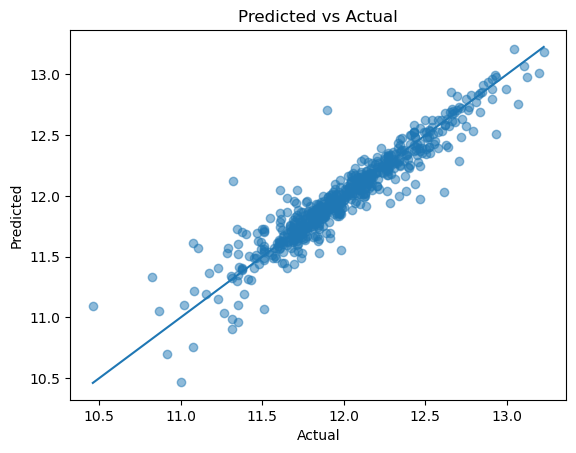

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

# perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [14]:
coverage = np.mean((y_test >= y_lower) & (y_test <= y_upper))
print("Coverage:", coverage)

Coverage: 0.8805460750853242


In [15]:
print(np.__version__)

1.24.3


In [16]:
import random
random.seed(42)

arr = np.array([1, 2, 3,4,5,6,7,8,9,0])
arr[[7,8,9]]
rng = np.random.default_rng(seed=42)
array_1d = rng.integers(1, 8, size=3)
array_1d


array([1, 6, 5])

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import random
# convert to real prices
y_pred_real  = np.expm1(y_pred)
y_lower_real = np.expm1(y_lower)
y_upper_real = np.expm1(y_upper)

# take 8 samples
n = 8
rng = np.random.default_rng(seed=42)
random_points = rng.integers(0,586,size=8)
print(random_points)
means = y_pred_real[random_points]
lower = y_lower_real[random_points]
upper = y_upper_real[random_points]

labels = [f"House {i+1}" for i in range(n)]
y_pos = np.arange(n)

[ 52 453 383 257 253 503  50 408]


In [18]:
print(random.randint(0,586))

114


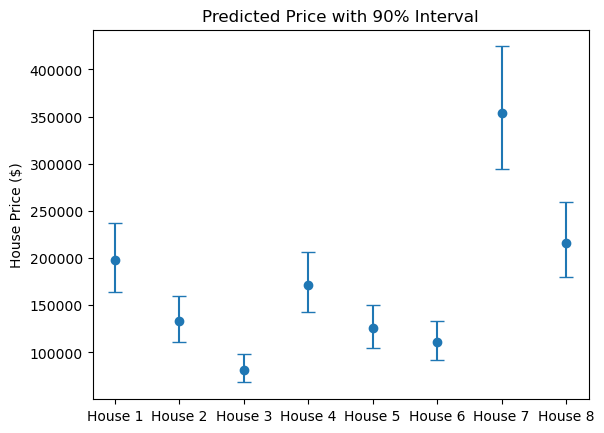

In [19]:
import numpy as np
import matplotlib.pyplot as plt

n = len(means)
x_pos = np.arange(n)
labels = [f"House {i+1}" for i in range(n)]

plt.figure()

plt.errorbar(
    x_pos,
    means,
    yerr=[means - lower, upper - means],
    fmt='o',
    capsize=5
)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Predicted Price with 90% Interval")

plt.show()

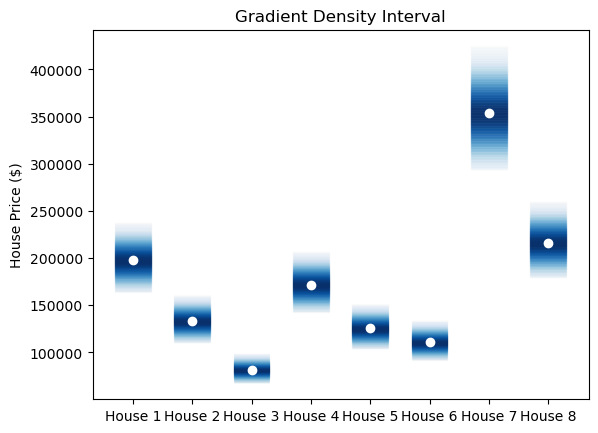

In [20]:
plt.figure()

for i in range(n):
    y = np.linspace(lower[i], upper[i], 200)
    center = means[i]
    
    density = np.exp(-((y - center)**2) / (2 * ((upper[i]-lower[i])/4)**2))
    density = density / density.max()
    
    for j in range(len(y)-1):
        plt.fill_between(
            [i-0.3, i+0.3],
            y[j], y[j+1],
            color=plt.cm.Blues(density[j]),
            alpha=density[j]*0.6
        )
    
    plt.scatter(i, center, color="white", zorder=3)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Gradient Density Interval")
plt.show()

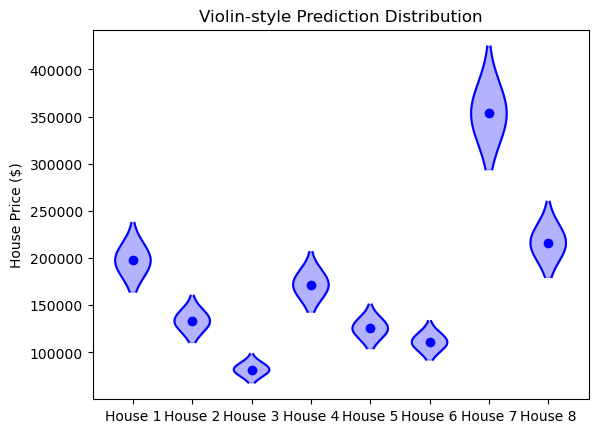

In [21]:
from scipy.stats import norm

plt.figure()

colors = plt.cm.tab10(np.linspace(0, 1, n))  # 👈 ADD THIS

for i in range(n):
    y = np.linspace(lower[i], upper[i], 200)
    mu = means[i]
    sigma = (upper[i] - lower[i]) / 4

    density = norm.pdf(y, mu, sigma)
    density = density / density.max() * 0.3

    c = "blue"

    plt.plot(i + density, y, color=c)
    plt.plot(i - density, y, color=c)
    plt.fill_betweenx(y, i - density, i + density, alpha=0.3, color=c)

    plt.scatter(i, mu, color=c)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Violin-style Prediction Distribution")
plt.show()

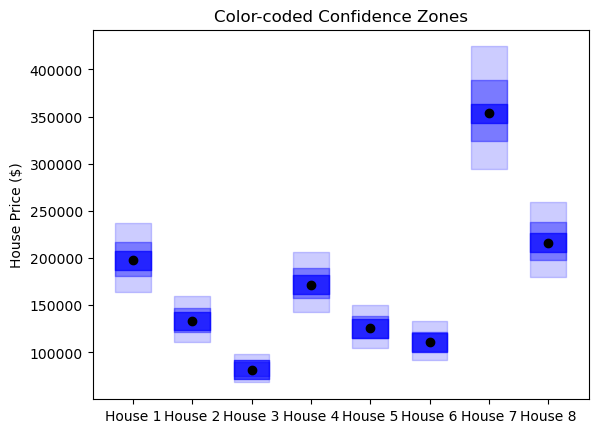

In [22]:
plt.figure()
c = "blue"

for i in range(n):
    mid_low = means[i] - (means[i] - lower[i]) / 2
    mid_high = means[i] + (upper[i] - means[i]) / 2

    # outer zone
    plt.fill_between([i-0.3, i+0.3],
                     lower[i], upper[i],
                     color=c, alpha=0.2)

    # mid zone
    plt.fill_between([i-0.3, i+0.3],
                     mid_low, mid_high,
                     color=c, alpha=0.4)

    # center zone
    plt.fill_between([i-0.3, i+0.3],
                     means[i]-10000,
                     means[i]+10000,
                     color=c, alpha=0.7)

    plt.scatter(i, means[i], color="black", zorder=3)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Color-coded Confidence Zones")
plt.show()

In [23]:
for i in range(n):
    print(
        f"{labels[i]}: Model predicts ${means[i]:,.0f}; "
        f"90% likely between ${lower[i]:,.0f} and ${upper[i]:,.0f}"
    )

House 1: Model predicts $197,518; 90% likely between $164,445 and $237,243
House 2: Model predicts $133,270; 90% likely between $110,954 and $160,073
House 3: Model predicts $81,738; 90% likely between $68,051 and $98,177
House 4: Model predicts $171,804; 90% likely between $143,037 and $206,357
House 5: Model predicts $125,439; 90% likely between $104,435 and $150,667
House 6: Model predicts $110,846; 90% likely between $92,286 and $133,140
House 7: Model predicts $353,331; 90% likely between $294,168 and $424,393
House 8: Model predicts $216,144; 90% likely between $179,952 and $259,615


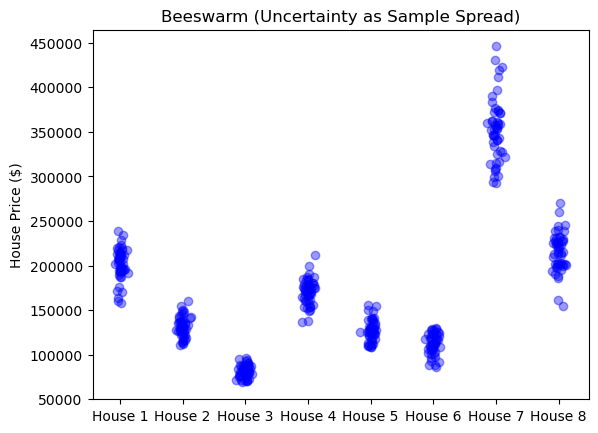

In [24]:
c = "blue"   # pick one color

plt.figure()

for i in range(n):
    samples = np.random.normal(
        means[i],
        (upper[i] - lower[i]) / 4,
        size=50
    )

    x_jitter = np.random.normal(i, 0.05, size=len(samples))

    plt.scatter(x_jitter, samples, color=c, alpha=0.4)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Beeswarm (Uncertainty as Sample Spread)")
plt.show()

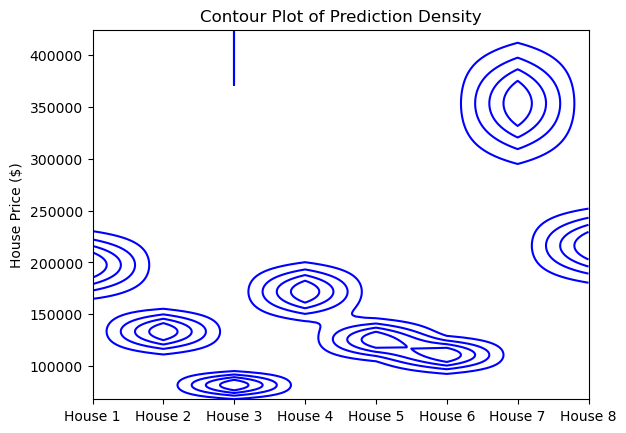

In [25]:
plt.figure()
grid_y = np.linspace(min(lower), max(upper), 300)

X, Y = np.meshgrid(x_pos, grid_y)
Z = np.zeros_like(X, dtype=float)

for i in range(n):
    mu = means[i]
    sigma = (upper[i] - lower[i]) / 4
    col = norm.pdf(grid_y, mu, sigma)
    Z[:, i] = col / col.max()  # normalise each house independently so contours stay separate

plt.contour(X, Y, Z, levels=5, colors="blue")

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Contour Plot of Prediction Density")
plt.show()

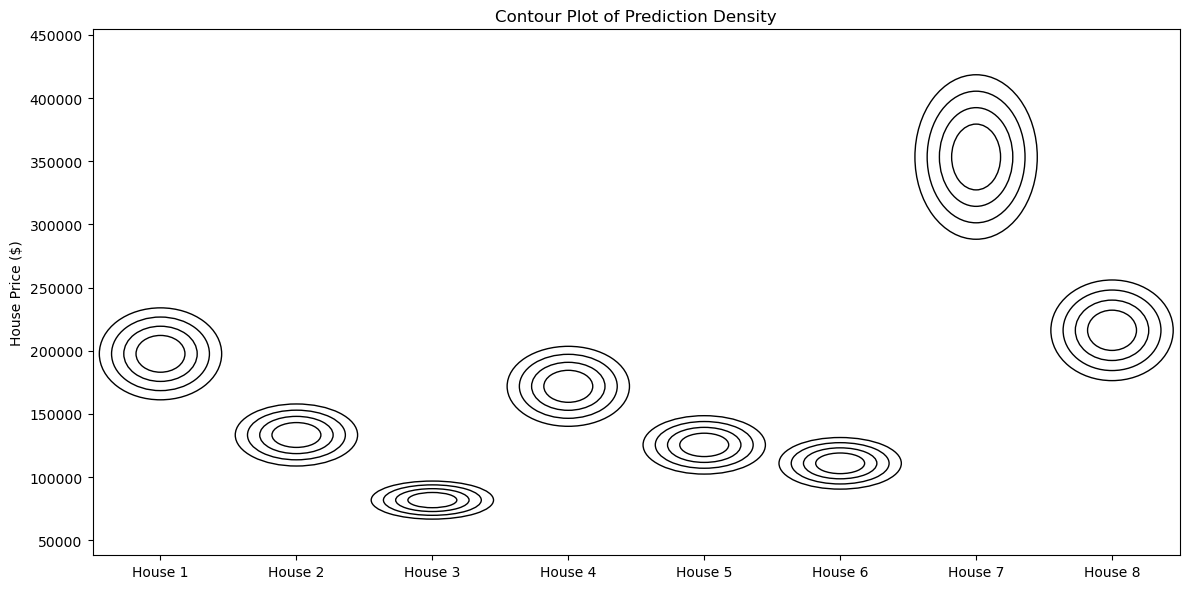

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(n):
    mu = means[i]

    spread_y = upper[i] - lower[i]

    if spread_y < 20000:
        spread_y = 20000

    for scale in [1.0, 0.8, 0.6, 0.4]:
        ellipse = Ellipse(
            (i, mu),
            width=0.9 * scale,
            height=spread_y * scale,
            fill=False
        )
        ax.add_patch(ellipse)

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(min(lower) - 30000, max(upper) + 30000)

ax.set_xticks(np.arange(n))
ax.set_xticklabels(labels)
ax.set_ylabel("House Price ($)")
ax.set_title("Contour Plot of Prediction Density")

plt.tight_layout()
plt.show()

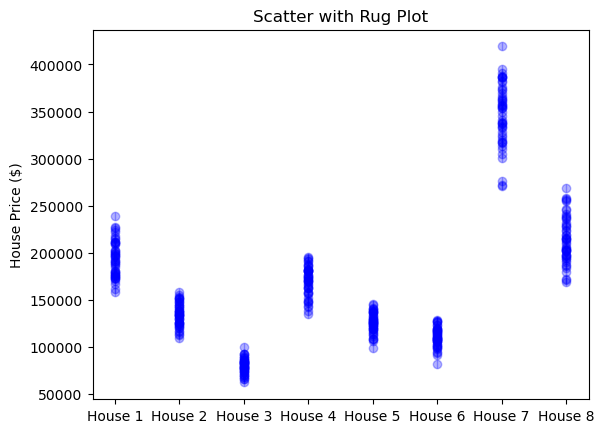

In [27]:
c = "blue"

plt.figure()

for i in range(n):
    samples = np.random.normal(
        means[i],
        (upper[i] - lower[i]) / 4,
        size=50
    )

    plt.scatter([i]*len(samples), samples,
                color=c, alpha=0.3)

    plt.plot([i]*len(samples), samples,
             '|', color=c, alpha=0.3)

plt.xticks(x_pos, labels)
plt.ylabel("House Price ($)")
plt.title("Scatter with Rug Plot")
plt.show()

In [28]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [29]:
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.pyplot as plt
import numpy as np

n = len(means)
x_pos = np.arange(n)

fig, ax = plt.subplots()

def update(frame):
    ax.clear()

    samples = []
    for i in range(n):
        sample = np.random.normal(
            means[i],
            (upper[i] - lower[i]) / 4
        )
        samples.append(sample)

    ax.scatter(x_pos, samples)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"House {i+1}" for i in range(n)])
    ax.set_ylabel("House Price ($)")
    ax.set_title("HOP: Possible Outcomes")
    ax.set_ylim(min(lower), max(upper))

ani = FuncAnimation(fig, update, frames=10, interval=200)

writer = PillowWriter(fps=5)

ani.save("hop.gif", writer=writer)

plt.close(fig)

In [30]:
from scipy.stats import skew

for i in range(n):
    samples = np.random.normal(
        means[i],
        (upper[i] - lower[i]) / 4,
        size=1000   # more samples = better estimate
    )

    s = skew(samples)
    print(f"House {i+1} skewness: {s:.3f}")

House 1 skewness: 0.075
House 2 skewness: -0.119
House 3 skewness: -0.105
House 4 skewness: -0.122
House 5 skewness: -0.019
House 6 skewness: 0.000
House 7 skewness: -0.021
House 8 skewness: -0.057


## 9. Generate  4 datasets and save images



In [33]:
import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Ellipse

os.makedirs("images", exist_ok=True)

y_pred_real  = np.expm1(y_pred)
y_lower_real = np.expm1(y_lower)
y_upper_real = np.expm1(y_upper)


def generate_all_graphs(dataset_id, sample_seed):
    rng = np.random.default_rng(seed=sample_seed)
    pts = rng.integers(0, len(y_pred_real), size=1)  # 1 data point per graph

    means  = y_pred_real[pts]
    lower  = y_lower_real[pts]
    upper  = y_upper_real[pts]

    n      = 1
    x_pos  = np.arange(n)
    labels = [f"House {i+1}" for i in range(n)]
    s      = f"_d{dataset_id}"

    print(f"Dataset {dataset_id} (seed={sample_seed})  index: {pts[0]}")

    # 1. Error Bars
    fig, ax = plt.subplots()
    ax.errorbar(x_pos, means, yerr=[means - lower, upper - means], fmt='o', capsize=5)
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("House Price ($)"); ax.set_title("Predicted Price with 90% Interval")
    fig.savefig(f"images/error_bars{s}.png", bbox_inches='tight'); plt.close(fig)

    # 2. Gradient Density Interval
    fig, ax = plt.subplots()
    for i in range(n):
        y = np.linspace(lower[i], upper[i], 200)
        center  = means[i]
        density = np.exp(-((y - center)**2) / (2 * ((upper[i] - lower[i]) / 4)**2))
        density /= density.max()
        for j in range(len(y) - 1):
            ax.fill_between([i - 0.3, i + 0.3], y[j], y[j+1],
                            color=plt.cm.Blues(density[j]), alpha=density[j] * 0.6)
        ax.scatter(i, center, color="white", zorder=3)
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("House Price ($)"); ax.set_title("Gradient Density Interval")
    fig.savefig(f"images/gradient_density{s}.png", bbox_inches='tight'); plt.close(fig)

    # 3. Violin-style Distribution
    fig, ax = plt.subplots()
    for i in range(n):
        y     = np.linspace(lower[i], upper[i], 200)
        mu    = means[i]
        sigma = (upper[i] - lower[i]) / 4
        dens  = norm.pdf(y, mu, sigma); dens = dens / dens.max() * 0.3
        ax.plot(i + dens, y, color="blue"); ax.plot(i - dens, y, color="blue")
        ax.fill_betweenx(y, i - dens, i + dens, alpha=0.3, color="blue")
        ax.scatter(i, mu, color="blue")
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("House Price ($)"); ax.set_title("Violin-style Prediction Distribution")
    fig.savefig(f"images/violin{s}.png", bbox_inches='tight'); plt.close(fig)

    # 4. Color-coded Confidence Zones
    fig, ax = plt.subplots()
    for i in range(n):
        mid_low  = means[i] - (means[i] - lower[i]) / 2
        mid_high = means[i] + (upper[i] - means[i]) / 2
        ax.fill_between([i-0.3, i+0.3], lower[i], upper[i], color="blue", alpha=0.2)
        ax.fill_between([i-0.3, i+0.3], mid_low, mid_high, color="blue", alpha=0.4)
        ax.fill_between([i-0.3, i+0.3], means[i]-10000, means[i]+10000, color="blue", alpha=0.7)
        ax.scatter(i, means[i], color="black", zorder=3)
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("House Price ($)"); ax.set_title("Color-coded Confidence Zones")
    fig.savefig(f"images/confidence{s}.png", bbox_inches='tight'); plt.close(fig)

    # 5. Beeswarm
    rng2 = np.random.default_rng(seed=sample_seed + 1000)
    fig, ax = plt.subplots()
    for i in range(n):
        samples  = rng2.normal(means[i], (upper[i] - lower[i]) / 4, size=50)
        x_jitter = rng2.normal(i, 0.05, size=50)
        ax.scatter(x_jitter, samples, color="blue", alpha=0.4)
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("House Price ($)"); ax.set_title("Beeswarm (Uncertainty as Sample Spread)")
    fig.savefig(f"images/beeswarm{s}.png", bbox_inches='tight'); plt.close(fig)

    # 6. Contour Plot (Ellipse)
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(n):
        mu       = means[i]
        spread_y = upper[i] - lower[i]
        if spread_y < 20000:
            spread_y = 20000
        for scale in [1.0, 0.8, 0.6, 0.4]:
            ellipse = Ellipse(
                (i, mu),
                width=0.9 * scale,
                height=spread_y * scale,
                fill=False,
                edgecolor="blue"
            )
            ax.add_patch(ellipse)
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(float(min(lower)) - 30000, float(max(upper)) + 30000)
    ax.set_xticks(np.arange(n)); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("House Price ($)"); ax.set_title("Contour Plot of Prediction Density")
    fig.tight_layout()
    fig.savefig(f"images/contour{s}.png", bbox_inches='tight'); plt.close(fig)

    # 7. Scatter with Rug Plot
    rng3 = np.random.default_rng(seed=sample_seed + 2000)
    fig, ax = plt.subplots()
    for i in range(n):
        samples = rng3.normal(means[i], (upper[i]-lower[i])/4, size=50)
        ax.scatter([i]*50, samples, color="blue", alpha=0.3)
        ax.plot([i]*50, samples, '|', color="blue", alpha=0.3)
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("House Price ($)"); ax.set_title("Scatter with Rug Plot")
    fig.savefig(f"images/scatter_rug{s}.png", bbox_inches='tight'); plt.close(fig)

    # 8. HOP Animation
    rng4 = np.random.default_rng(seed=sample_seed + 3000)
    hop_fig, hop_ax = plt.subplots()
    def update(frame):
        hop_ax.clear()
        samples = [rng4.normal(means[i], (upper[i]-lower[i])/4) for i in range(n)]
        hop_ax.scatter(x_pos, samples)
        hop_ax.set_xticks(x_pos); hop_ax.set_xticklabels(labels, rotation=15)
        hop_ax.set_ylabel("House Price ($)"); hop_ax.set_title("HOP: Possible Outcomes")
        hop_ax.set_ylim(float(min(lower)) - 20000, float(max(upper)) + 20000)
    ani = FuncAnimation(hop_fig, update, frames=10, interval=200)
    ani.save(f"images/hop{s}.gif", writer=PillowWriter(fps=5))
    plt.close(hop_fig)

    print(f"  done — 8 graphs saved.\n")

print("Ready — run the next cell to generate all 12 datasets.")

Ready — run the next cell to generate all 12 datasets.


In [34]:
DATASET_SEEDS = {
    1: 42,  2: 123,  3: 456,  4: 789,  5: 1012,
    6: 135, 7: 638,  8: 921,  9: 222,  10: 357,
    11: 500, 12: 777
}

for dataset_id, seed in DATASET_SEEDS.items():
    generate_all_graphs(dataset_id, seed)

import glob
print("Done — files saved:")
for f in sorted(glob.glob("images/*_d[0-9].png") + glob.glob("images/*_d[0-9][0-9].png")
              + glob.glob("images/*_d[0-9].gif") + glob.glob("images/*_d[0-9][0-9].gif")):
    print(" ", f)

Dataset 1 (seed=42)  index: 52
  done — 8 graphs saved.

Dataset 2 (seed=123)  index: 9
  done — 8 graphs saved.

Dataset 3 (seed=456)  index: 206
  done — 8 graphs saved.

Dataset 4 (seed=789)  index: 315
  done — 8 graphs saved.

Dataset 5 (seed=1012)  index: 434
  done — 8 graphs saved.

Dataset 6 (seed=135)  index: 279
  done — 8 graphs saved.

Dataset 7 (seed=638)  index: 502
  done — 8 graphs saved.

Dataset 8 (seed=921)  index: 143
  done — 8 graphs saved.

Dataset 9 (seed=222)  index: 239
  done — 8 graphs saved.

Dataset 10 (seed=357)  index: 366
  done — 8 graphs saved.

Dataset 11 (seed=500)  index: 386
  done — 8 graphs saved.

Dataset 12 (seed=777)  index: 531
  done — 8 graphs saved.

Done — files saved:
  images/beeswarm_d1.png
  images/beeswarm_d10.png
  images/beeswarm_d11.png
  images/beeswarm_d12.png
  images/beeswarm_d2.png
  images/beeswarm_d3.png
  images/beeswarm_d4.png
  images/beeswarm_d5.png
  images/beeswarm_d6.png
  images/beeswarm_d7.png
  images/beeswarm_d